# Trabalho Final - Inteligência Computacional

Este notebook apresenta todos os experimentos de regressão e classificação multiclasse conforme solicitado.

## Estrutura
- Importação de bibliotecas
- Carregamento dos dados
    - Regressão
        - Energy Efficiency Dataset
        - California Housing
    - Classificação
        - Wine Quality Dataset
        - Iris
- Pré-processamento
    - Regressão
        - Energy Efficiency Dataset
        - California Housing
    - Classificação
        - Wine Quality Dataset
        - Iris
- Configuração dos algoritmos
    - Regressão:
        - Regressão Linear
        - Random Forest Regressor
        - MLPRegressor (Rede Neural)
        - SVR (Support Vector Regressor)
        - FuzzyRegressor (exemplo simples usando lógica fuzzy)
    - Classificação:
        - Regressão Logística (LogisticRegression)
        - Random Forest Classifier
        - MLPClassifier (Rede Neural Multicamadas)
        - SVM Classifier (Support Vector Machine)
    - Métricas de Avaliação
- Execução dos experimentos
    - Experimento 01 - Regressão
        - Setup 1 - Energy Efficiency Dataset
            - Regressão Linear
            - Random Forest Regressor
            - MLPRegressor (Rede Neural)
            - SVR (Support Vector Regressor)
            - FuzzyRegressor (exemplo simples usando lógica fuzzy)
        - Setup 2 - California Housing
            - Regressão Linear
            - Random Forest Regressor
            - MLPRegressor (Rede Neural)
            - SVR (Support Vector Regressor)
            - FuzzyRegressor (exemplo simples usando lógica fuzzy)
    - Experimento 02 - Classificação Multiclasse
        - Setup 1 - Wine Quality Dataset
            - Regressão Logística (LogisticRegression)
            - Random Forest Classifier
            - MLPClassifier (Rede Neural Multicamadas)
            - SVM Classifier (Support Vector Machine)
        - Setup 2 - Iris
            - Regressão Logística (LogisticRegression)
            - Random Forest Classifier
            - MLPClassifier (Rede Neural Multicamadas)
            - SVM Classifier (Support Vector Machine)
- Análise dos resultados
- Justificativas e análise crítica

%pip install -r requirements.txt

In [ ]:
# Importação das bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score, f1_score, cohen_kappa_score
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.svm import SVR, SVC
import warnings
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
from sklearn.metrics import ConfusionMatrixDisplay
from imblearn.over_sampling import RandomOverSampler

warnings.filterwarnings('ignore')

import os

# Garante que a pasta 'graficos' existe
os.makedirs('graficos', exist_ok=True)

## Carregamento dos Dados
Serão utilizados os seguintes datasets:
- Regressão: `energy_efficiency.csv`, `california_housing.csv`
- Classificação: `winequality_red.csv`, `iris.csv`
Os arquivos estão na pasta `datasets_salvos/`.

In [2]:
# Carregando os datasets
energy = pd.read_csv('datasets_salvos/energy_efficiency.csv')
california = pd.read_csv('datasets_salvos/california_housing.csv')
wine = pd.read_csv('datasets_salvos/winequality_red.csv')
iris = pd.read_csv('datasets_salvos/iris.csv')
print('Energy Efficiency Dataset:')
display(energy.head())
print('California Housing Dataset:')
display(california.head())
print('Wine Quality Red Dataset:')
display(wine.head())
print('Iris Dataset:')
display(iris.head())

Energy Efficiency Dataset:


,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


California Housing Dataset:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Wine Quality Red Dataset:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


Iris Dataset:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## Pré-processamento dos Dados
Serão aplicadas as etapas de tratamento de valores faltantes, normalização/padronização e codificação de variáveis categóricas.

In [ ]:
# Funções de pré-processamento
def preprocess_regression(df, target_cols):
    df = df.dropna()
    X = df.drop(columns=target_cols)
    y = df[target_cols]
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    return X_scaled, y
def preprocess_classification(df, target_col, balance=False):
    print(f'Tamanho do DataFrame antes do dropna: {df.shape}')
    df = df.dropna()
    print(f'Tamanho do DataFrame após o dropna e antes do balanceamento: {df.shape}')
    X = df.drop(columns=[target_col])
    y = df[target_col]
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)
    
    if balance:
        
        ros = RandomOverSampler(random_state=42)
        X_scaled, y = ros.fit_resample(X_scaled, y)
        print(f'Tamanho do DataFrame após o balanceamento : {X_scaled.shape}')
    return X_scaled, y
# Pré-processamento
X_energy, y_energy = preprocess_regression(energy, ['Y1', 'Y2'])
X_california, y_california = preprocess_regression(california, ['MedHouseVal'])
X_wine, y_wine = preprocess_classification(wine, 'quality', balance=True)  
X_iris, y_iris = preprocess_classification(iris, 'target', balance=False)  

## Configuração dos Algoritmos

### Métricas

In [4]:
def plot_confusion_matrix(model, X_test, y_test, title='Matriz de Confusão', filename=None):
    plt.figure(figsize=(6,6))
    # Gera a matriz de confusão já normalizada em porcentagem
    disp = ConfusionMatrixDisplay.from_estimator(
        model, X_test, y_test, cmap=plt.cm.Blues, normalize='true'
    )
    plt.title(f"{title} (Porcentagem)")
    # Remove os valores absolutos (deixa só a porcentagem)
    # O próprio ConfusionMatrixDisplay já imprime os valores normalizados
    # Ajusta os valores para mostrar como porcentagem (em vez de fração)
    cm = disp.confusion_matrix
    n_classes = cm.shape[0]
    # Atualiza os textos para mostrar porcentagem
    for text in disp.text_.ravel():
        val = float(text.get_text())
        text.set_text(f"{val*100:.1f}%")
    plt.savefig(f'graficos/{filename}.png', bbox_inches='tight')
    plt.show()

def plot_regression_scatter(y_true, y_pred, title='Dispersão - Regressão', filename=None):
    plt.figure(figsize=(6,6))
    plt.scatter(y_true, y_pred, alpha=0.7)
    plt.xlabel('Valor Real')
    plt.ylabel('Valor Previsto')
    plt.title(title)
    plt.grid(True)
    plt.savefig(f'graficos/{filename}.png', bbox_inches='tight')
    plt.show()

In [5]:
def regression_metrics(y_true, y_pred):
    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
    rmse = mean_squared_error(y_true, y_pred) ** 0.5  # Calcula RMSE manualmente
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {'RMSE': rmse, 'MAE': mae, 'R2': r2}

def classification_metrics(y_true, y_pred):
    from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score
    return {
        'Acuracia': accuracy_score(y_true, y_pred),
        'F1-score': f1_score(y_true, y_pred, average='weighted'),
        'Kappa': cohen_kappa_score(y_true, y_pred)
    }

### Regressão

In [6]:
def train_linear_regression(X, y):
    model = LinearRegression()
    model.fit(X, y)
    return model

def train_random_forest_regressor(X, y):
    model = RandomForestRegressor(n_estimators=100)
    model.fit(X, y)
    return model

def train_mlp_regressor(X, y):
    model = MLPRegressor(max_iter=500)
    model.fit(X, y)
    return model

def train_svr(X, y):
    model = SVR(kernel='rbf')
    model.fit(X, y)
    return model

### Treinamento de Classificação

In [7]:
def train_logistic_regression(X, y):
    model = LogisticRegression(max_iter=500)
    model.fit(X, y)
    return model

def train_random_forest_classifier(X, y):
    model = RandomForestClassifier(n_estimators=100)
    model.fit(X, y)
    return model

def train_mlp_classifier(X, y):
    model = MLPClassifier(max_iter=500)
    model.fit(X, y)
    return model

def train_svm_classifier(X, y):
    model = SVC(kernel='rbf', probability=True)
    model.fit(X, y)
    return model

## Execução dos Experimentos
Serão realizados experimentos de regressão e classificação com 30 repetições para cada modelo e base. Com 70 para treinamento e 30 de texte. 

### Regressão

In [8]:
def run_regression_experiment(X, y, train_fn, seeds=range(1, 31), test_size=0.3, plot=False):
    results = []
    y_true_all = []
    y_pred_all = []
    for seed in seeds:
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)
        model = train_fn(X_train, y_train)
        y_pred = model.predict(X_test)
        metrics = regression_metrics(y_test, y_pred)
        results.append(metrics)
        # Guarda os valores da última repetição para o gráfico
        if seed == seeds[-1]:
            y_true_all = y_test
            y_pred_all = y_pred
    df_results = pd.DataFrame(results)
    # Mostra médias e desvios padrão
    print("Médias das métricas:\n", df_results.mean())
    print("\nDesvio padrão das métricas:\n", df_results.std())
    # Plota apenas uma vez, se solicitado
    if plot:
        # Corrige o nome do arquivo para evitar caracteres inválidos
        func_name = (
            train_fn.__name__
            if hasattr(train_fn, "__name__") and train_fn.__name__ != "<lambda>"
            else "LinearRegression"
        )
        plot_regression_scatter(
            y_true_all, y_pred_all,
            title=f'Dispersão - {func_name}',
            filename=f'{func_name}_final'
        )
    return df_results

### Classificação 

In [9]:
def run_classification_experiment(X, y, train_fn, seeds=range(1, 31), test_size=0.2, plot=False):
    results = []
    last_model = None
    last_X_test = None
    last_y_test = None
    for seed in seeds:
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)
        model = train_fn(X_train, y_train)
        y_pred = model.predict(X_test)
        metrics = classification_metrics(y_test, y_pred)
        results.append(metrics)
        # Guarda para plotar só uma vez ao final
        if seed == seeds[-1]:
            last_model = model
            last_X_test = X_test
            last_y_test = y_test
    df_results = pd.DataFrame(results)
    print("Médias das métricas:\n", df_results.mean())
    print("\nDesvio padrão das métricas:\n", df_results.std())
    if plot:
        plot_confusion_matrix(
            last_model, last_X_test, last_y_test,
            title=f'Matriz de Confusão - {type(last_model).__name__}',
            filename=f'{type(last_model).__name__}_final'
        )
    return df_results

## Experimento 01 - Regressão

In [10]:
regression_results = {}

### Setup 1 - Energy Efficiency Dataset
#### Energy Efficiency Y1

##### Regressão Linear

Médias das métricas:
 RMSE    2.970777
MAE     2.109132
R2      0.912785
dtype: float64

Desvio padrão das métricas:
 RMSE    0.125832
MAE     0.102541
R2      0.007878
dtype: float64


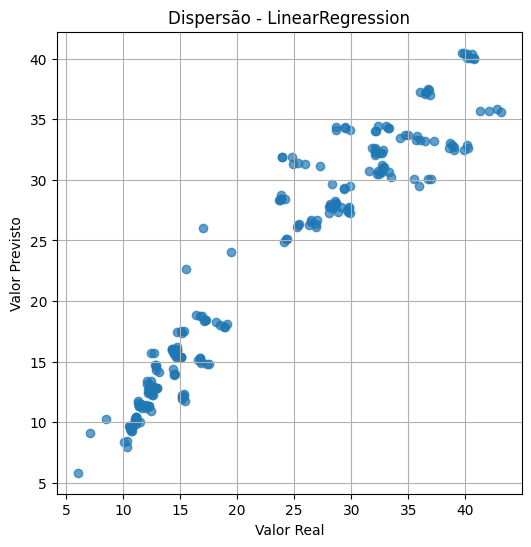


Modelo: LinearRegression (Energy Y1)
            RMSE        MAE         R2
count  30.000000  30.000000  30.000000
mean    2.970777   2.109132   0.912785
std     0.125832   0.102541   0.007878
min     2.766455   1.918429   0.893855
25%     2.857538   2.039246   0.909378
50%     2.973330   2.104002   0.913402
75%     3.064747   2.171273   0.916508
max     3.289209   2.335462   0.925401


In [11]:
# Executa o experimento de regressão linear para prever Y1 e exibe estatísticas descritivas dos resultados.
res_lr = run_regression_experiment(X_energy, y_energy['Y1'], lambda X, y: LinearRegression().fit(X, y), plot=True)
regression_results['Energy_LinearRegression_Y1'] = res_lr
print('\nModelo: LinearRegression (Energy Y1)')
print(res_lr.describe())


##### Random Forest Regressor

Médias das métricas:
 RMSE    0.518026
MAE     0.345082
R2      0.997294
dtype: float64

Desvio padrão das métricas:
 RMSE    0.077828
MAE     0.022831
R2      0.000985
dtype: float64


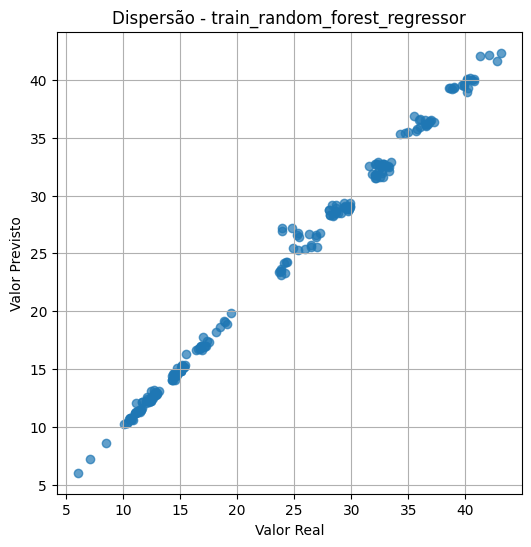


Modelo: RandomForest (Energy Y1)
            RMSE        MAE         R2
count  30.000000  30.000000  30.000000
mean    0.518026   0.345082   0.997294
std     0.077828   0.022831   0.000985
min     0.444060   0.308195   0.992714
25%     0.476565   0.332790   0.997266
50%     0.499119   0.342170   0.997582
75%     0.525224   0.351273   0.997692
max     0.870806   0.420310   0.998027


In [12]:
# Executa o experimento usando Random Forest para prever Y1 e exibe estatísticas descritivas dos resultados.
res_rf = run_regression_experiment(X_energy, y_energy['Y1'], train_random_forest_regressor, plot=True)
regression_results['Energy_RandomForest_Y1'] = res_rf
print('\nModelo: RandomForest (Energy Y1)')
print(res_rf.describe())

##### MLPRegressor (Rede Neural Multicamadas)

Médias das métricas:
 RMSE    2.634495
MAE     1.856083
R2      0.931249
dtype: float64

Desvio padrão das métricas:
 RMSE    0.152194
MAE     0.110217
R2      0.008894
dtype: float64


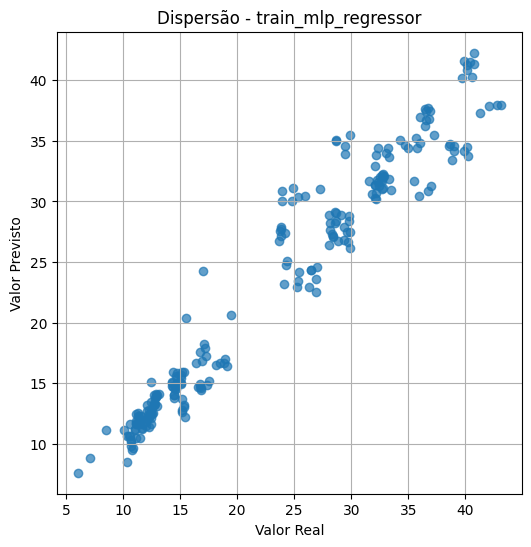


Modelo: MLPRegressor (Energy Y1)
            RMSE        MAE         R2
count  30.000000  30.000000  30.000000
mean    2.634495   1.856083   0.931249
std     0.152194   0.110217   0.008894
min     2.341791   1.643852   0.902636
25%     2.522546   1.783860   0.926195
50%     2.624596   1.848559   0.931577
75%     2.727127   1.918007   0.937966
max     3.150229   2.217844   0.946869


In [13]:
# Executa o experimento usando rede neural MLP para prever Y1 e exibe estatísticas descritivas dos resultados.
res_mlp = run_regression_experiment(X_energy, y_energy['Y1'], train_mlp_regressor, plot=True)
regression_results['Energy_MLP_Y1'] = res_mlp
print('\nModelo: MLPRegressor (Energy Y1)')
print(res_mlp.describe())

##### SVR (Support Vector Regressor)

Médias das métricas:
 RMSE    2.828952
MAE     1.902756
R2      0.920956
dtype: float64

Desvio padrão das métricas:
 RMSE    0.161032
MAE     0.119438
R2      0.007839
dtype: float64


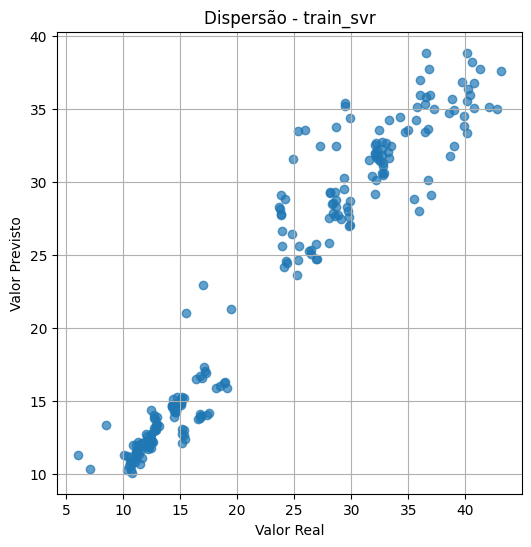


Modelo: SVR (Energy Y1)
            RMSE        MAE         R2
count  30.000000  30.000000  30.000000
mean    2.828952   1.902756   0.920956
std     0.161032   0.119438   0.007839
min     2.532087   1.716402   0.900799
25%     2.694044   1.806502   0.915757
50%     2.813123   1.901167   0.920582
75%     2.949709   1.985282   0.927088
max     3.198202   2.170321   0.932138


In [14]:

# Executa o experimento usando SVR para prever Y1 e exibe estatísticas descritivas dos resultados.
res_svr = run_regression_experiment(X_energy, y_energy['Y1'], train_svr, plot=True)
regression_results['Energy_SVR_Y1'] = res_svr
print('\nModelo: SVR (Energy Y1)')
print(res_svr.describe())


#### Energy Efficiency Y2

##### Regressão Linear

Médias das métricas:
 RMSE    3.205850
MAE     2.271299
R2      0.884940
dtype: float64

Desvio padrão das métricas:
 RMSE    0.209776
MAE     0.132068
R2      0.011241
dtype: float64


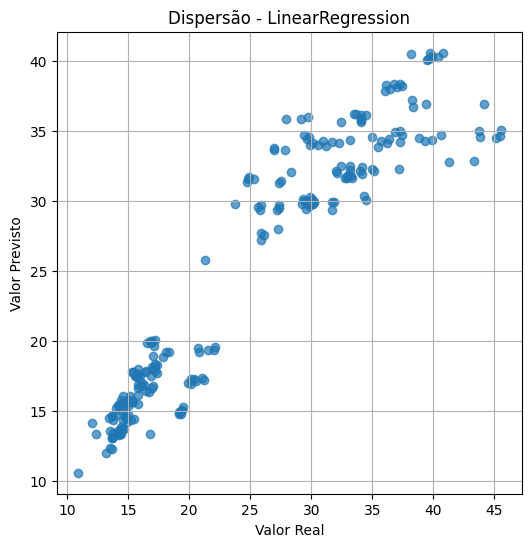


Modelo: LinearRegression (Energy Y2)
            RMSE        MAE         R2
count  30.000000  30.000000  30.000000
mean    3.205850   2.271299   0.884940
std     0.209776   0.132068   0.011241
min     2.840911   2.035552   0.864124
25%     3.034906   2.205099   0.875335
50%     3.173195   2.255143   0.887511
75%     3.361542   2.373863   0.892975
max     3.660411   2.543625   0.903092


In [15]:
# Executa o experimento usando regressão linear e exibe estatísticas descritivas dos resultados.
res_lr2 = run_regression_experiment(X_energy, y_energy['Y2'], lambda X, y: LinearRegression().fit(X, y), plot=True)
regression_results['Energy_LinearRegression_Y2'] = res_lr2
print('\nModelo: LinearRegression (Energy Y2)')
print(res_lr2.describe())

##### Random Forest Regressor

Médias das métricas:
 RMSE    1.723907
MAE     1.044680
R2      0.966540
dtype: float64

Desvio padrão das métricas:
 RMSE    0.141301
MAE     0.086833
R2      0.005654
dtype: float64


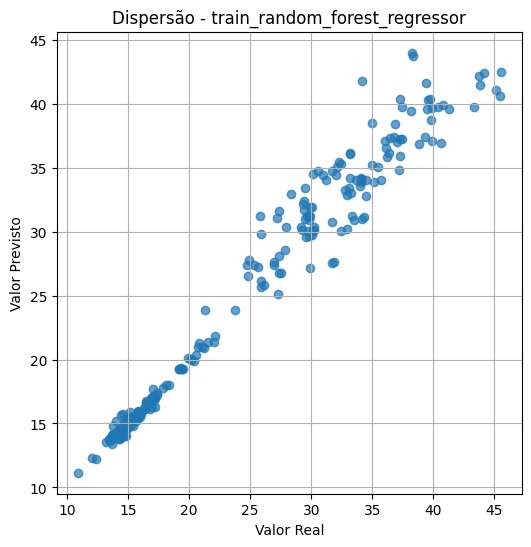


Modelo: RandomForest (Energy Y2)
            RMSE        MAE         R2
count  30.000000  30.000000  30.000000
mean    1.723907   1.044680   0.966540
std     0.141301   0.086833   0.005654
min     1.468258   0.903902   0.951128
25%     1.648244   0.986724   0.965496
50%     1.681295   1.020382   0.968120
75%     1.748697   1.091804   0.969875
max     2.118060   1.263560   0.973298


In [16]:
# Executa o experimento usando Random Forest e exibe estatísticas descritivas dos resultados.
res_rf2 = run_regression_experiment(X_energy, y_energy['Y2'], train_random_forest_regressor, plot=True)
regression_results['Energy_RandomForest_Y2'] = res_rf2
print('\nModelo: RandomForest (Energy Y2)')
print(res_rf2.describe())

##### MLPRegressor (Rede Neural Multicamadas)

Médias das métricas:
 RMSE    2.998123
MAE     2.124794
R2      0.899211
dtype: float64

Desvio padrão das métricas:
 RMSE    0.235664
MAE     0.149310
R2      0.012988
dtype: float64


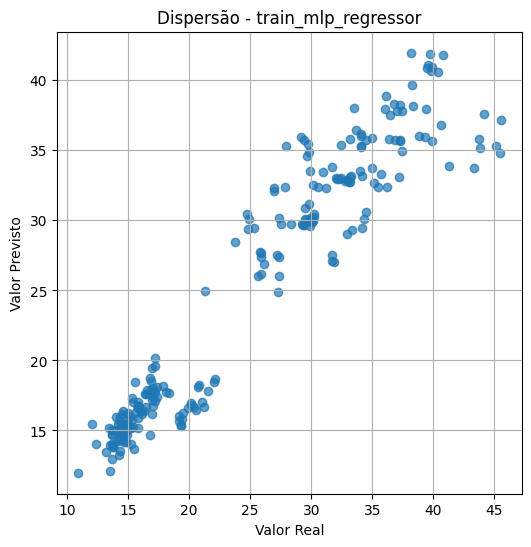


Modelo: MLPRegressor (Energy Y2)
            RMSE        MAE         R2
count  30.000000  30.000000  30.000000
mean    2.998123   2.124794   0.899211
std     0.235664   0.149310   0.012988
min     2.587074   1.828473   0.867573
25%     2.855210   2.016486   0.891129
50%     2.982552   2.119128   0.898676
75%     3.133841   2.205956   0.908510
max     3.534035   2.431087   0.921301


In [17]:
# Executa o experimento usando rede neural MLP e exibe estatísticas descritivas dos resultados.
res_mlp2 = run_regression_experiment(X_energy, y_energy['Y2'], train_mlp_regressor, plot=True)
regression_results['Energy_MLP_Y2'] = res_mlp2
print('\nModelo: MLPRegressor (Energy Y2)')
print(res_mlp2.describe())



##### SVR (Support Vector Regressor)

Médias das métricas:
 RMSE    3.169571
MAE     2.110367
R2      0.887523
dtype: float64

Desvio padrão das métricas:
 RMSE    0.241211
MAE     0.154561
R2      0.012713
dtype: float64


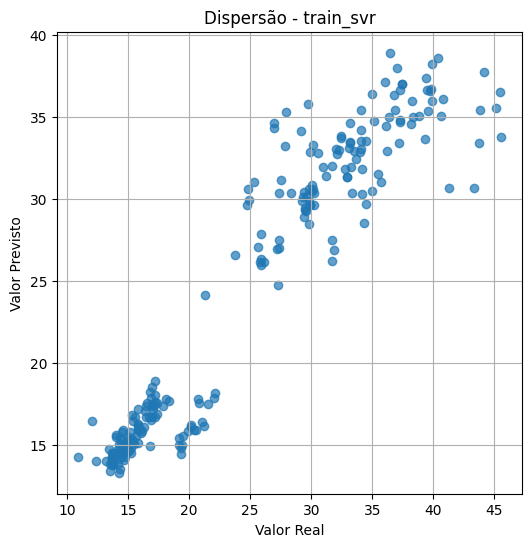


Modelo: SVR (Energy Y2)
            RMSE        MAE         R2
count  30.000000  30.000000  30.000000
mean    3.169571   2.110367   0.887523
std     0.241211   0.154561   0.012713
min     2.755544   1.845336   0.859743
25%     3.012494   2.009130   0.878700
50%     3.148489   2.125561   0.887885
75%     3.331880   2.205992   0.896725
max     3.703175   2.424603   0.906603


In [18]:
# Executa o experimento usando SVR e exibe estatísticas descritivas dos resultados.

res_svr2 = run_regression_experiment(X_energy, y_energy['Y2'], train_svr, plot=True)
regression_results['Energy_SVR_Y2'] = res_svr2
print('\nModelo: SVR (Energy Y2)')
print(res_svr2.describe())



### Setup 2 - California Housing
#### California Housing

##### Regressão Linear

Médias das métricas:
 RMSE    0.736095
MAE     0.532678
R2      0.591793
dtype: float64

Desvio padrão das métricas:
 RMSE    0.044257
MAE     0.005661
R2      0.054170
dtype: float64


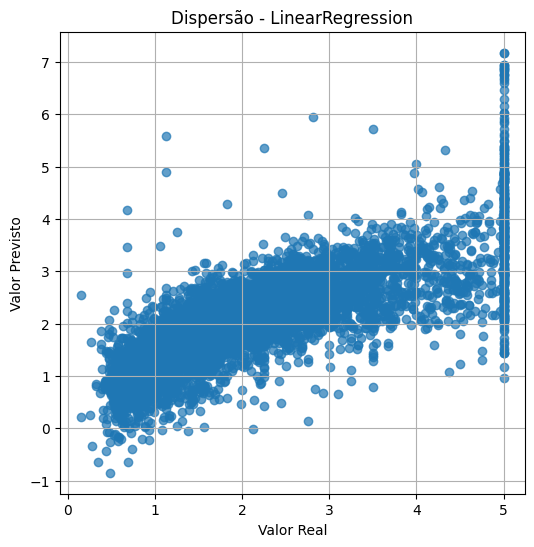


Modelo: LinearRegression (California Housing)
            RMSE        MAE         R2
count  30.000000  30.000000  30.000000
mean    0.736095   0.532678   0.591793
std     0.044257   0.005661   0.054170
min     0.699475   0.521820   0.309561
25%     0.722349   0.529449   0.592635
50%     0.728179   0.532285   0.602260
75%     0.733898   0.535161   0.607176
max     0.964204   0.546579   0.626203


In [19]:
res_lr_c = run_regression_experiment(X_california, y_california, lambda X, y: LinearRegression().fit(X, y), plot=True)
regression_results['California_LinearRegression'] = res_lr_c
print('\nModelo: LinearRegression (California Housing)')
print(res_lr_c.describe())


##### Random Forest Regressor

Médias das métricas:
 RMSE    0.506771
MAE     0.331339
R2      0.807086
dtype: float64

Desvio padrão das métricas:
 RMSE    0.010501
MAE     0.006529
R2      0.006897
dtype: float64


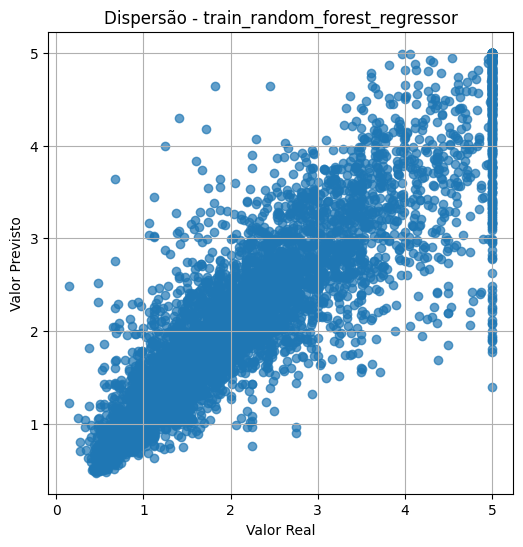


Modelo: RandomForest (California Housing)
            RMSE        MAE         R2
count  30.000000  30.000000  30.000000
mean    0.506771   0.331339   0.807086
std     0.010501   0.006529   0.006897
min     0.483609   0.319329   0.794648
25%     0.500362   0.326773   0.801110
50%     0.507899   0.332169   0.808644
75%     0.512924   0.334858   0.811563
max     0.532155   0.347611   0.818147


In [20]:
res_rf_c = run_regression_experiment(X_california, y_california, train_random_forest_regressor, plot=True)
regression_results['California_RandomForest'] = res_rf_c
print('\nModelo: RandomForest (California Housing)')
print(res_rf_c.describe())


##### MLPRegressor (Rede Neural Multicamadas)

Médias das métricas:
 RMSE    0.543744
MAE     0.372064
R2      0.777873
dtype: float64

Desvio padrão das métricas:
 RMSE    0.011635
MAE     0.006621
R2      0.009064
dtype: float64


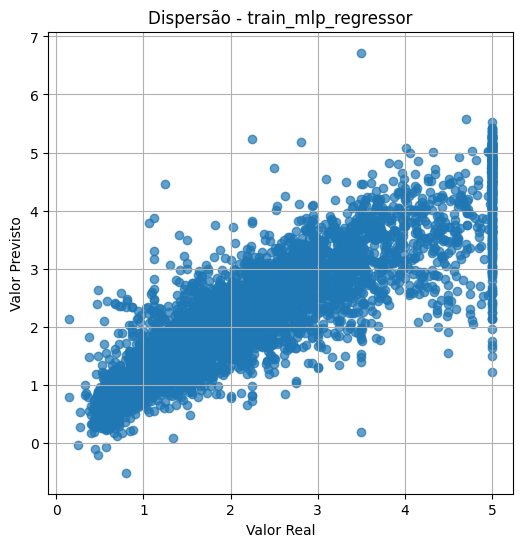


Modelo: MLPRegressor (California Housing)
            RMSE        MAE         R2
count  30.000000  30.000000  30.000000
mean    0.543744   0.372064   0.777873
std     0.011635   0.006621   0.009064
min     0.521116   0.360687   0.758278
25%     0.537287   0.368146   0.771673
50%     0.545196   0.371959   0.777151
75%     0.550488   0.375920   0.783633
max     0.567459   0.386402   0.795234


In [21]:
res_mlp_c = run_regression_experiment(X_california, y_california, train_mlp_regressor, plot=True)
regression_results['California_MLP'] = res_mlp_c
print('\nModelo: MLPRegressor (California Housing)')
print(res_mlp_c.describe())

##### SVR (Support Vector Regressor)

In [ ]:

res_svr_c = run_regression_experiment(X_california, y_california, train_svr, plot=True)
regression_results['California_SVR'] = res_svr_c
print('\nModelo: SVR (California Housing)')
print(res_svr_c.describe())


## Experimento 02 - Classificação Multiclasse

In [ ]:
# Experimentos de Classificação
classification_results = {}

### Setup 1 - Wine Quality Dataset

#### Regressão Logística

Médias das métricas:
 Acuracia    0.589271
F1-score    0.554383
Kappa       0.309574
dtype: float64

Desvio padrão das métricas:
 Acuracia    0.027838
F1-score    0.033127
Kappa       0.042358
dtype: float64


<Figure size 600x600 with 0 Axes>

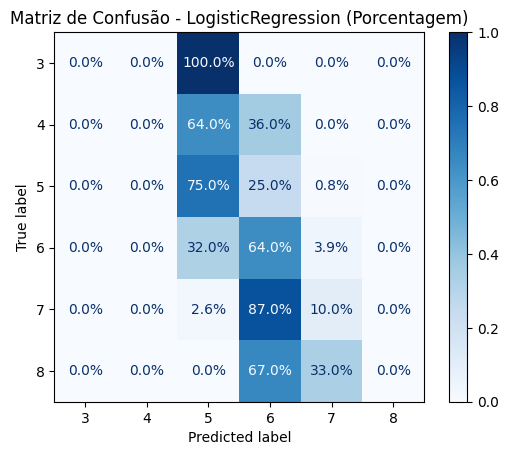


Modelo: LogisticRegression (Wine Quality)
        Acuracia   F1-score      Kappa
count  30.000000  30.000000  30.000000
mean    0.589271   0.554383   0.309574
std     0.027838   0.033127   0.042358
min     0.509375   0.454002   0.192750
25%     0.575781   0.542275   0.287262
50%     0.587500   0.559127   0.305928
75%     0.606250   0.576778   0.330869
max     0.646875   0.617566   0.400560


In [ ]:


res_log_wine = run_classification_experiment(X_wine, y_wine, train_logistic_regression, plot=True)
classification_results['Wine_LogisticRegression'] = res_log_wine
print('\nModelo: LogisticRegression (Wine Quality)')
print(res_log_wine.describe())
# Executa o experimento de classificação usando regressão logística e exibe estatísticas descritivas dos resultados.


#### Random Forest Classifier

Médias das métricas:
 Acuracia    0.699896
F1-score    0.682596
Kappa       0.510784
dtype: float64

Desvio padrão das métricas:
 Acuracia    0.026826
F1-score    0.028223
Kappa       0.041651
dtype: float64


<Figure size 600x600 with 0 Axes>

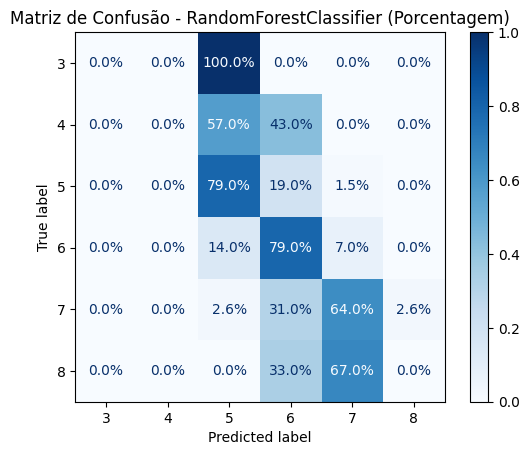


Modelo: RandomForest (Wine Quality)
        Acuracia   F1-score      Kappa
count  30.000000  30.000000  30.000000
mean    0.699896   0.682596   0.510784
std     0.026826   0.028223   0.041651
min     0.650000   0.620509   0.438394
25%     0.675781   0.656524   0.480551
50%     0.700000   0.684520   0.515170
75%     0.718750   0.703543   0.533258
max     0.750000   0.736543   0.587090


In [ ]:
res_rf_wine = run_classification_experiment(X_wine, y_wine, train_random_forest_classifier, plot=True)
classification_results['Wine_RandomForest'] = res_rf_wine
print('\nModelo: RandomForest (Wine Quality)')
print(res_rf_wine.describe())


#### MLPClassifier (Rede Neural Multicamadas)

Médias das métricas:
 Acuracia    0.612083
F1-score    0.593397
Kappa       0.364808
dtype: float64

Desvio padrão das métricas:
 Acuracia    0.020198
F1-score    0.022363
Kappa       0.032100
dtype: float64


<Figure size 600x600 with 0 Axes>

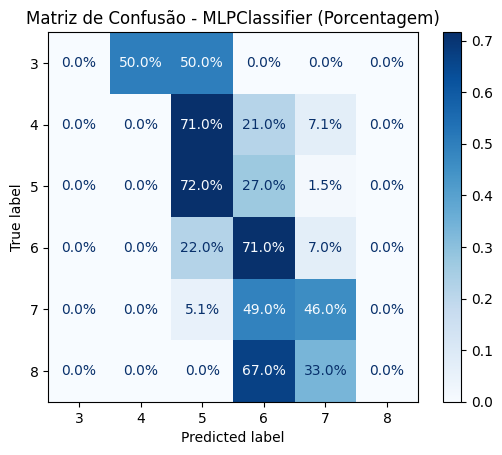


Modelo: MLPClassifier (Wine Quality)
        Acuracia   F1-score      Kappa
count  30.000000  30.000000  30.000000
mean    0.612083   0.593397   0.364808
std     0.020198   0.022363   0.032100
min     0.571875   0.547381   0.309706
25%     0.597656   0.575913   0.343113
50%     0.612500   0.595603   0.362660
75%     0.627344   0.608753   0.378789
max     0.646875   0.638360   0.432072


In [ ]:
res_mlp_wine = run_classification_experiment(X_wine, y_wine, train_mlp_classifier, plot=True)
classification_results['Wine_MLP'] = res_mlp_wine
print('\nModelo: MLPClassifier (Wine Quality)')
print(res_mlp_wine.describe())

#### SVM Classifier (Support Vector Machine)

Médias das métricas:
 Acuracia    0.608750
F1-score    0.580545
Kappa       0.345207
dtype: float64

Desvio padrão das métricas:
 Acuracia    0.022955
F1-score    0.025860
Kappa       0.034777
dtype: float64


<Figure size 600x600 with 0 Axes>

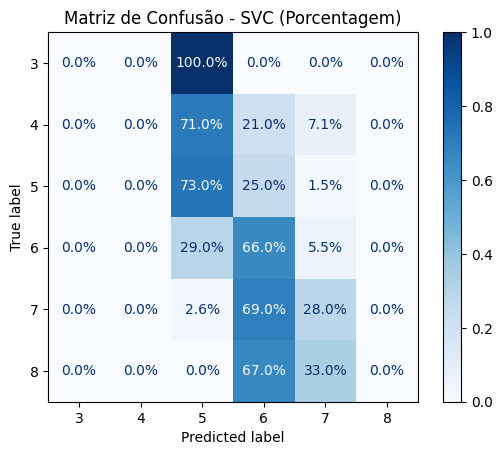


Modelo: SVMClassifier (Wine Quality)
        Acuracia   F1-score      Kappa
count  30.000000  30.000000  30.000000
mean    0.608750   0.580545   0.345207
std     0.022955   0.025860   0.034777
min     0.556250   0.515687   0.274458
25%     0.597656   0.568427   0.322741
50%     0.604688   0.580417   0.340471
75%     0.625000   0.597239   0.364133
max     0.650000   0.627285   0.414348


In [ ]:
res_svm_wine = run_classification_experiment(X_wine, y_wine, train_svm_classifier, plot=True)
classification_results['Wine_SVM'] = res_svm_wine
print('\nModelo: SVMClassifier (Wine Quality)')
print(res_svm_wine.describe())
# Executa o experimento usando SVM para classificação e exibe estatísticas descritivas dos resultados.

### Setup 2 -  Iris Dataset

#### Regressão Logística

Médias das métricas:
 Acuracia    0.918889
F1-score    0.918758
Kappa       0.876090
dtype: float64

Desvio padrão das métricas:
 Acuracia    0.062320
F1-score    0.062799
Kappa       0.094343
dtype: float64


<Figure size 600x600 with 0 Axes>

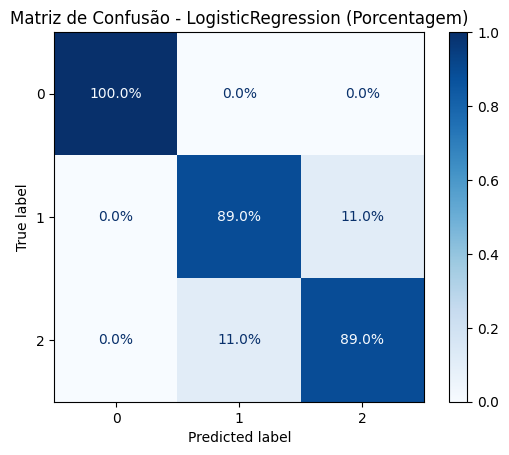


Modelo: LogisticRegression (Iris)
        Acuracia   F1-score      Kappa
count  30.000000  30.000000  30.000000
mean    0.918889   0.918758   0.876090
std     0.062320   0.062799   0.094343
min     0.766667   0.764000   0.643463
25%     0.900000   0.900192   0.847908
50%     0.933333   0.933333   0.898819
75%     0.966667   0.966869   0.948623
max     1.000000   1.000000   1.000000


In [ ]:
res_log_iris = run_classification_experiment(X_iris, y_iris, train_logistic_regression, plot=True)
classification_results['Iris_LogisticRegression'] = res_log_iris
print('\nModelo: LogisticRegression (Iris)')
print(res_log_iris.describe())


#### Random Forest Classifier

Médias das métricas:
 Acuracia    0.945556
F1-score    0.945215
Kappa       0.916205
dtype: float64

Desvio padrão das métricas:
 Acuracia    0.045891
F1-score    0.046788
Kappa       0.070885
dtype: float64


<Figure size 600x600 with 0 Axes>

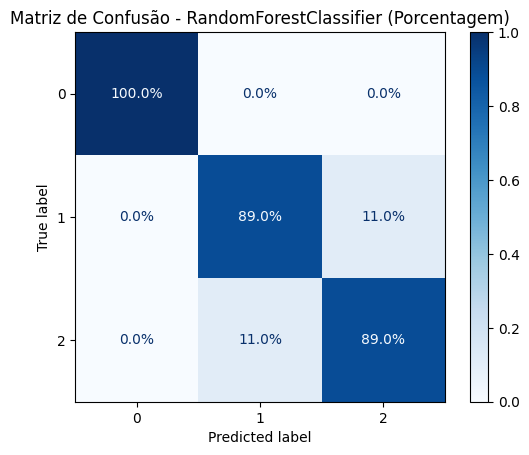


Modelo: RandomForest (Iris)
        Acuracia   F1-score      Kappa
count  30.000000  30.000000  30.000000
mean    0.945556   0.945215   0.916205
std     0.045891   0.046788   0.070885
min     0.833333   0.823362   0.741379
25%     0.908333   0.908834   0.861903
50%     0.966667   0.965977   0.945686
75%     0.966667   0.967192   0.949854
max     1.000000   1.000000   1.000000


In [ ]:
res_rf_iris = run_classification_experiment(X_iris, y_iris, train_random_forest_classifier, plot=True)
classification_results['Iris_RandomForest'] = res_rf_iris
print('\nModelo: RandomForest (Iris)')
print(res_rf_iris.describe())
# Executa o experimento usando Random Forest para classificação e exibe estatísticas descritivas dos resultados.


#### MLPClassifier (Rede Neural Multicamadas)

Médias das métricas:
 Acuracia    0.952222
F1-score    0.952041
Kappa       0.925772
dtype: float64

Desvio padrão das métricas:
 Acuracia    0.037837
F1-score    0.038071
Kappa       0.059447
dtype: float64


<Figure size 600x600 with 0 Axes>

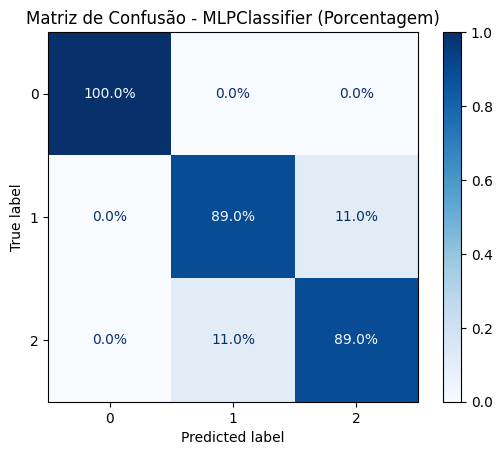


Modelo: MLPClassifier (Iris)
        Acuracia   F1-score      Kappa
count  30.000000  30.000000  30.000000
mean    0.952222   0.952041   0.925772
std     0.037837   0.038071   0.059447
min     0.866667   0.866667   0.795222
25%     0.933333   0.933106   0.897956
50%     0.966667   0.966573   0.948629
75%     0.966667   0.967078   0.949854
max     1.000000   1.000000   1.000000


In [ ]:
res_mlp_iris = run_classification_experiment(X_iris, y_iris, train_mlp_classifier, plot=True)
classification_results['Iris_MLP'] = res_mlp_iris
print('\nModelo: MLPClassifier (Iris)')
print(res_mlp_iris.describe())

#### SVM Classifier (Support Vector Machine)

Médias das métricas:
 Acuracia    0.952222
F1-score    0.952104
Kappa       0.926495
dtype: float64

Desvio padrão das métricas:
 Acuracia    0.038837
F1-score    0.039164
Kappa       0.059604
dtype: float64


<Figure size 600x600 with 0 Axes>

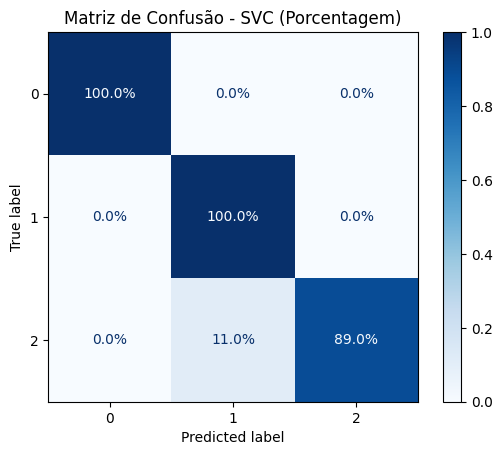


Modelo: SVMClassifier (Iris)
        Acuracia   F1-score      Kappa
count  30.000000  30.000000  30.000000
mean    0.952222   0.952104   0.926495
std     0.038837   0.039164   0.059604
min     0.866667   0.862271   0.794521
25%     0.933333   0.933106   0.897956
50%     0.966667   0.966399   0.947735
75%     0.966667   0.967207   0.949495
max     1.000000   1.000000   1.000000


In [ ]:

res_svm_iris = run_classification_experiment(X_iris, y_iris, train_svm_classifier, plot=True)
classification_results['Iris_SVM'] = res_svm_iris
print('\nModelo: SVMClassifier (Iris)')
print(res_svm_iris.describe())
# Executa o experimento usando SVM para classificação e exibe estatísticas descritivas dos resultados.

## Análise dos Resultados
Serão apresentados gráficos comparativos das métricas dos modelos para cada base de dados.

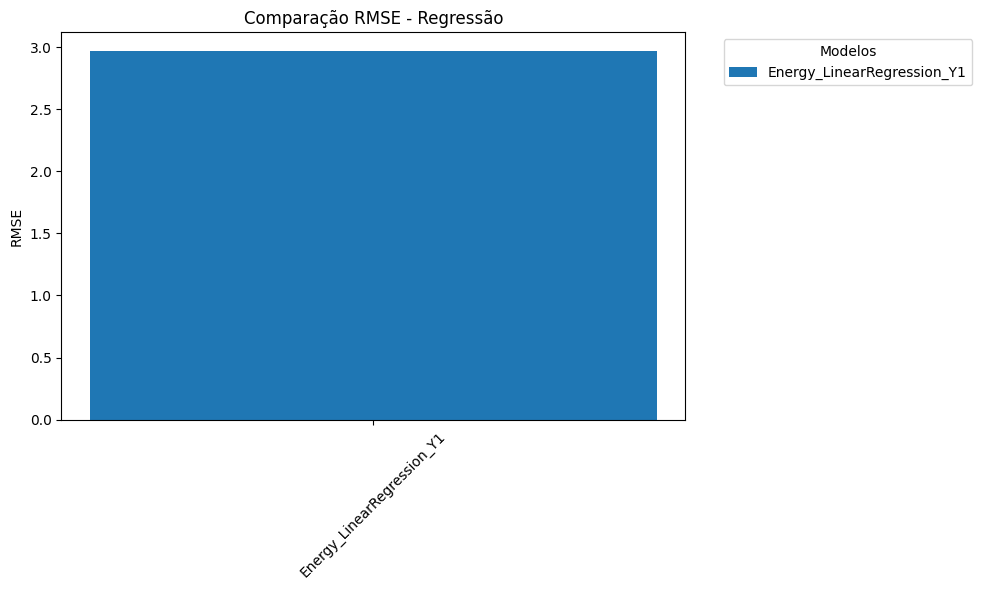

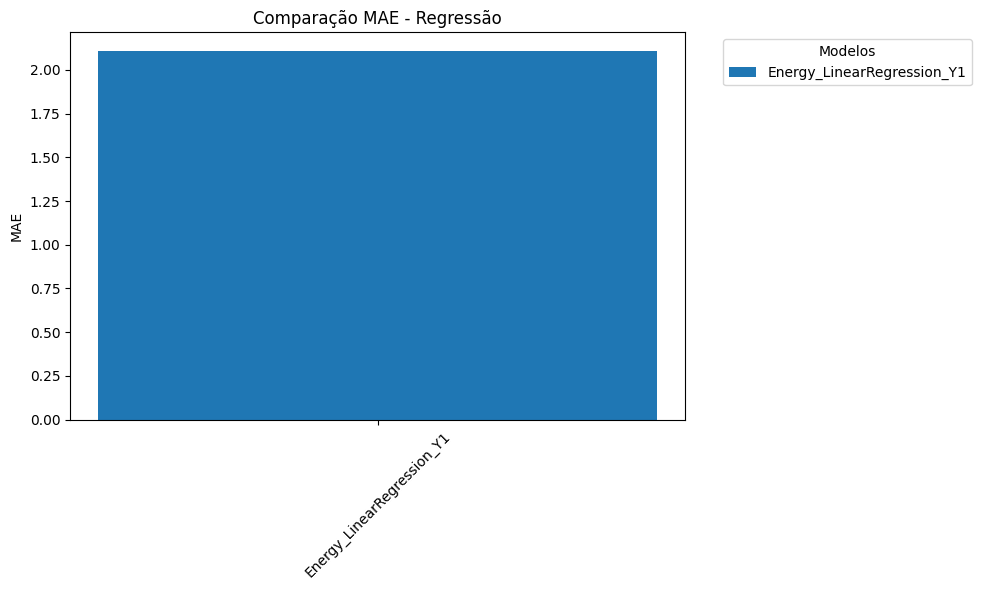

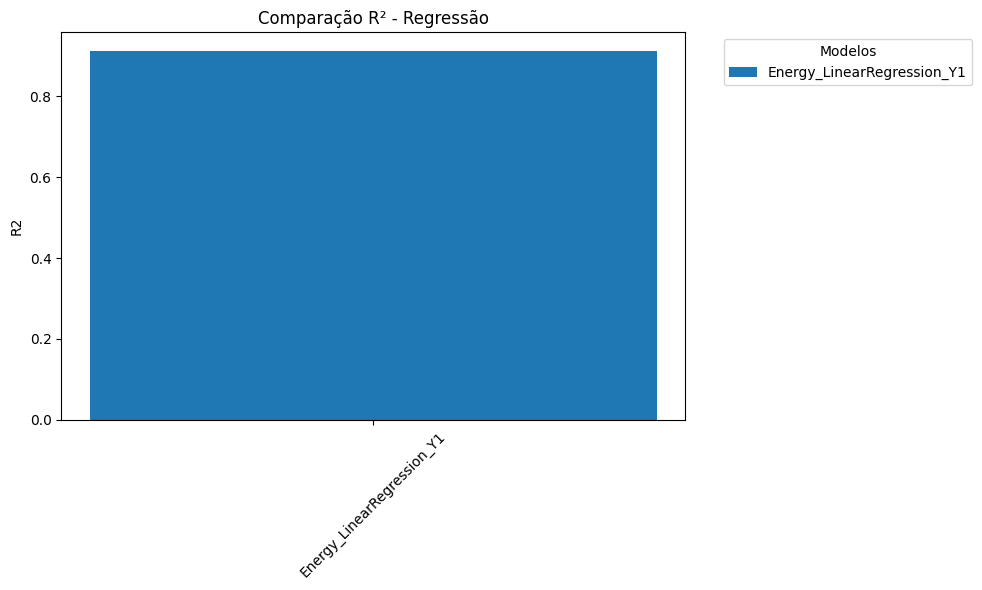

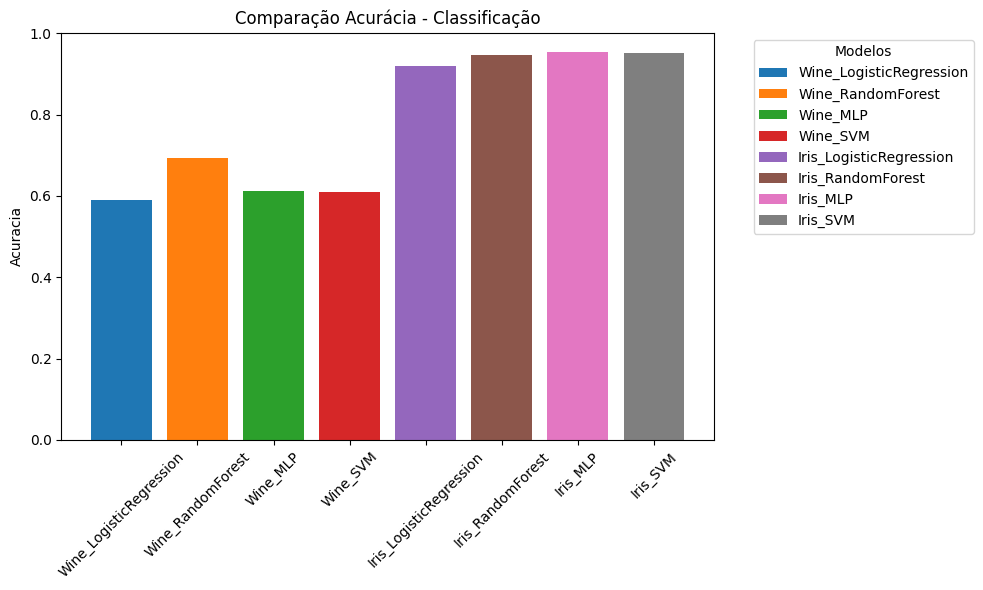

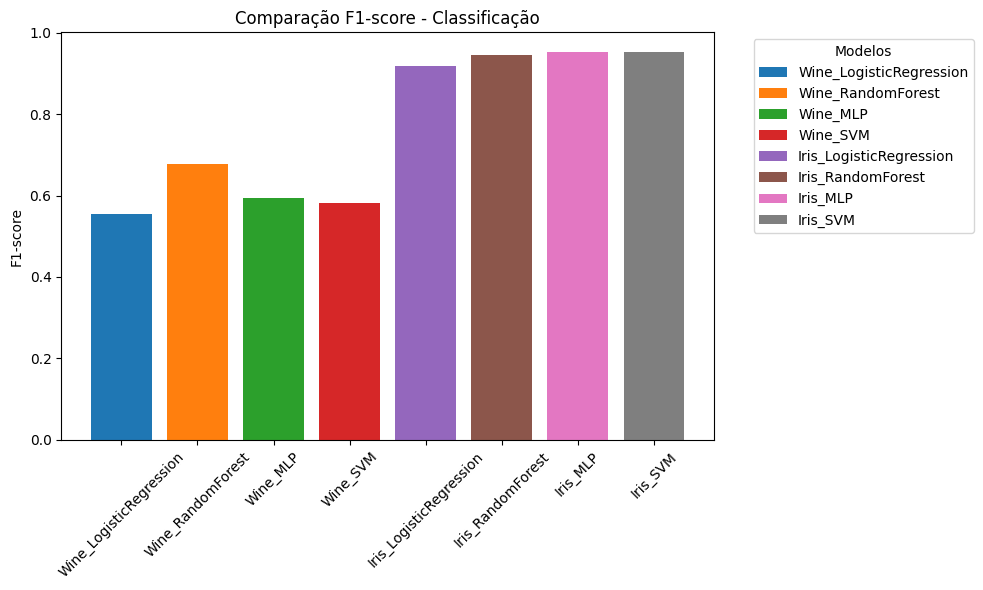

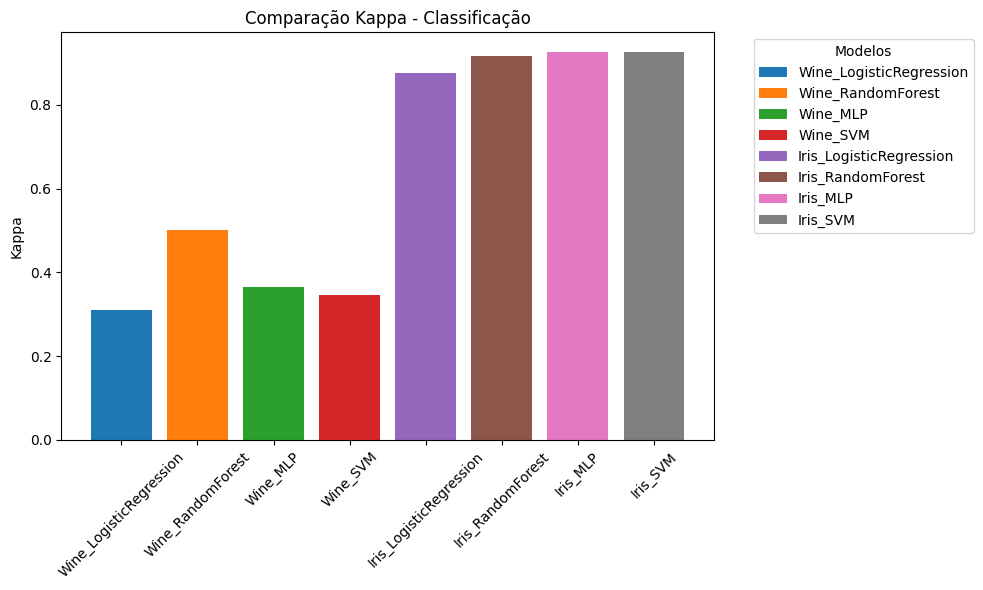

In [ ]:
# Gráficos comparativos das métricas dos modelos
def plot_metric_comparison(results_dict, metric, title, filename):
    plt.figure(figsize=(10,6))
    bars = []
    labels = []
    for key, df in results_dict.items():
        if metric in df.columns:
            bar = plt.bar(key, df[metric].mean(), label=key)
            bars.append(bar)
            labels.append(key)
    plt.ylabel(metric)
    plt.title(title)
    plt.xticks(rotation=45)
    plt.gca().set_xlabel("")  # Remove o nome do eixo x (mantém só os nomes dos modelos)
    plt.legend(labels, title="Modelos", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(f'graficos/{filename}.png', bbox_inches='tight')
    plt.show()

# Gráficos de regressão
plot_metric_comparison(regression_results, 'RMSE', 'Comparação RMSE - Regressão', 'comparacao_rmse_regressao')
plot_metric_comparison(regression_results, 'MAE', 'Comparação MAE - Regressão', 'comparacao_mae_regressao')
plot_metric_comparison(regression_results, 'R2', 'Comparação R² - Regressão', 'comparacao_r2_regressao')
# Gráficos de classificação
plot_metric_comparison(classification_results, 'Acuracia', 'Comparação Acurácia - Classificação', 'comparacao_acuracia_classificacao')
plot_metric_comparison(classification_results, 'F1-score', 'Comparação F1-score - Classificação', 'comparacao_f1_classificacao')
plot_metric_comparison(classification_results, 'Kappa', 'Comparação Kappa - Classificação', 'comparacao_kappa_classificacao')

## Justificativas e Análise Crítica
Os resultados obtidos mostram diferenças relevantes entre os algoritmos utilizados para cada tarefa. São destacados pontos como desempenho, robustez, interpretabilidade e importância do pré-processamento.

A realização de múltiplos experimentos e repetições garante maior confiabilidade estatística dos resultados.

### Gráficos comparativos separados por amostra (dataset)
Os gráficos a seguir apresentam a comparação das métricas dos modelos, separados por cada amostra (dataset). Essa separação facilita a análise individual do desempenho dos modelos em cada base de dados, conforme discutido no chat.